## 분류 모델
- 분류: 범주를 예측하는 모델
- 종류
    - 이진 분류: 두 가지 범주로 분류할 수 있는 경우
                (상승/하락, 스팸 여부, 연체 여부 등)
    - 다중 분류: 여러 가지 범주로 분류할 수 있는 경우
                (섹터 예측, 신용 등급 등)
> **이진 분류**는 지표가 명확하여 가장 많이 사용되는 형태.

우리가 가지고 있는 데이터(시세)에서 `수익률`, `거래량_비율`, `이평대비`, `변동성`
데이터를 활용하여 상승(up)/하락(down)으로 분류 가능.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, time_split, FEATURES, SEED

# acuuracy_score (정확도), f1_score (정밀도, 재현율의 조화평균)
from sklearn.metrics import accuracy_score, f1_score

setup()
pd.set_option("display.width", 130)

df = build_dataset()
train, test, cutoff = time_split(df)

tr = train.sample(15_000, random_state=SEED)
te = test.sample(4_000, random_state=SEED)

X_train, y_train = tr[FEATURES], tr["target_up"]
X_text, y_test = te[FEATURES], te["target_up"]

print(f"* 학습 {len(tr):,}행 ({tr['date'].min().date()} ~ {tr['date'].max().date()})")
print(f"* 테스트 {len(te):,}행 ({te['date'].min().date()} ~ {te['date'].max().date()})")

* 학습 15,000행 (2023-10-24 ~ 2026-01-16)
* 테스트 4,000행 (2026-01-19 ~ 2026-09-07)


## 분류 알고리즘(모델) 종류 (대표적인 6가지)
모든 알고리즘은 동일한 방식으로 사용할 수 있음.

```python
model = 어떤모델()

model.fit(X_train, y_train)
pred = model.predict(X_test)
score = model.score(X_test, y_test)
```

- 종류
    - LogisticRegression (로지스틱 회귀)\
      : 선형 회귀 방식을 분류에 적용한 모델. 데이터가 어떤 범주에 속할 확률을 0과 1 사이의 값(확률)으로 예측.
        - 스케일링 필요. 빠른 속도.
        - 결과 해석이 쉽지만 성능은 보통 수준.
    - DecisionTree (의사결정나무)\
      : 스무고개 하듯이 데이터의 특징을 기준으로 질문을 던져가며 데이터를 분류하는 직관적인 트리 구조의 모델.
        - 스케일링 불필요. 빠른 속도.
        - 모델 해석이 쉬운 편이나, 과적합 되기 쉬우므로 단일 모델로는 비교적 낮은 성능.
    - KNN (K-Nearest-Neighbors, K-최근접 이웃)\
      : 새로운 데이터를 예측할 때, 주변에 가장 가까이 있는 K개의 이웃 데이터들이 속한 범주를 다수결로 판별하는 방식. 즉, K개의 이웃들 중 가장 많은 이웃 데이터가 속한 범주로 보냄.
        - 거리 기반이므로 스케일링 필수.
        - 학습은 없으나 예측 속도가 느림.
        - 제한적인 해석만 가능하고, 성능은 보통 수준.
    - RandomForest (랜덤 포레스트)\
      : 여러 개의 의사결정나무를 만들고, 이들의 예측 결과를 취합(투표나 평균)하여 최종 결과를 도출하는 앙상블 기법. (앙상블 기법: 여러 개의 개별 모델을 조화롭게 묶어 더 정확하고 뛰어난 단일 예측 결과를 도출하는 기법(방법론).)
        - 스케일링 불필요. 보통의 속도.
        - 트리가 여러 개이므로 단일 트리에 비해 해석은 제한적이나, 성능이 매우 뛰어나고 안정적.
    - SVM (Support Vector Machine)\
      : 클래스들을 구분하는 최적의 경계선을 찾는 알고리즘. 경계에서 가장 가까운 데이터와의 마진을 최대화함.
        - 스케일링 필요. 매우 느린 학습/예측 속도.
        - 내부가 블랙박스 같아 모델 해석이 어려우나, 데이터에 따라서는 매우 뛰어난 성능을 발휘하기도 함.
    - GradientBoosting (그래디언트 부스팅)\
      : 이전 트리가 만든 예측의 오차를 다음 트리가 보완하는 방식으로, 여러 개의 트리를 순차 학습시키는 앙상블 기법.
        - 스케일링 불필요. 트리를 순차적으로 만들기 때문에 느린 속도. (앞의 트리가 끝나야 다음 트리 생성 가능.)
        - 해석은 제한적이나, 머신러닝 알고리즘 중 비교적 높은 수준의 성능.

In [ ]:
# 모델별로 성능 비교

# 다른 모델 성능을 비교할 기준선 생성용 분류기
from sklearn.dummy import DummyClassifier

# 앙상블 모델. 여러 개의 알고리즘이 합쳐진 모델.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 선형 모델
from sklearn.linear_model import LogisticRegression
# KNN 모델
from sklearn.neighbors import KNeighborsClassifier
# 의사결정나무
from sklearn.tree import DecisionTreeClassifier
# SVM 모델
from sklearn.svm import SVC

# 각 피처의 평균을 0, 표준편차를 1로 맞춰주는 StandardScaler
from sklearn.preprocessing import StandardScaler
# 전체 과정(전처리 ~ 모델 학습)을 묶기 위한 도구
from sklearn.pipeline import Pipeline

# 스케일링이 필요한 모델은 Pipeline으로 묶어서 관리
def with_scaler(model):
    return Pipeline(
        [   # (단계, 이 단계에 사용할 객체)
            ("sc", StandardScaler()),
            ("m", model)
        ]
    )

# SVM => 속도가 pow(데이터 수, 2)에 비례하여 느려짐. 표본을 줄여서 사용.
SVM_N = 3_000

# "모델": (객체, 샘플링_여부) 구조
# 샘플링 여부: 표본 수 변경 여부. True가 변경, False는 변경 안 함.
models = {
    "DummyClassifier": (DummyClassifier(strategy="most_frequent"), False),
    # 표본 수 변경 없음. max_iter: 학습을 반복할 최대 횟수 설정
    "LogisticRegression": (with_scaler(
                            LogisticRegression(max_iter=1_000, 
                                               random_state=SEED)), False),
    # False: 표본 수 변경 없음
    "DecisionTree(제한없음)": (DecisionTreeClassifier(random_state=SEED), False),
    # 최대 트리 깊이 5 제한. 제한이 없으면 결과가 나올 때까지 계속 트리가 깊어짐.
    "DecisionTree(제한있음)": (DecisionTreeClassifier(max_depth=5, 
                                                      random_state=SEED), False),
    "KNN(k=50)": (with_scaler(KNeighborsClassifier(n_neighbors=50, n_jobs=-1)), False),
    "RandomForest": (RandomForestClassifier(n_estimators=100, max_depth=6, 
                                            random_state=SEED, n_jobs= -1), False),
    "GradientBoosting": (GradientBoostingClassifier(n_estimators=100, max_depth=3, 
                                                    random_state=SEED), False),
    "SVM (표본의 크기 3000)": (with_scaler(SVC(random_state=SEED)), True)
}

# 결과(row)를 담을 빈 list
# -> {"모델": 모델명, "학습": score, "테스트": score, "f1": f1, "학습시간": 시간} 형태
rows = []
for name, (model, small) in models.items():
    # small 값에 따라 표본 수 줄이기 (0 ~ 3_000행 슬라이싱)
    Xtr = X_train.iloc[:SVM_N] if small else X_train
    ytr = y_train.iloc[:SVM_N] if small else y_train

    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    # 모델별 학습시간 기록
    fit_time = time.perf_counter() - t0

    pred = model.predict(X_text)

    rows.append({
        "모델": name,
        # 이 model.score가 DummyClassifier보다 낮으면?
        # => 제대로 학습하지 못했다고 판단할 수 있다.
        "학습": model.score(Xtr, ytr),
        # model.score() 값과 accuracy_score() 값의 차이가 크면?
        # => 과적합이라고 판단 가능.
        "테스트": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "학습시간": fit_time
    })

result = pd.DataFrame(rows)
print(result.round(4).to_string(index=False))

                모델     학습    테스트     F1   학습시간
   DummyClassifier 0.5069 0.5175 0.0000 0.0190
LogisticRegression 0.5107 0.4805 0.3859 0.0138
DecisionTree(제한없음) 1.0000 0.5005 0.4893 0.1353
DecisionTree(제한있음) 0.5219 0.4810 0.5245 0.0340
         KNN(k=50) 0.5672 0.5178 0.4708 0.0116
      RandomForest 0.6105 0.4932 0.4269 0.1587
  GradientBoosting 0.5987 0.4960 0.4434 2.0431
 SVM (표본의 크기 3000) 0.5720 0.4915 0.3787 0.1296


> DecisionTree(제한없음)의 model.score()값이 1로 나타나는데, 이건 답지를 외운 것으로 볼 수 있다. 특히, 테스트 점수(accuracy_score()값)와 학습 점수(model.score()값)의 차이가 거의 1/2이므로 과적합에 해당한다.

## 분류 모델 성능 결과

- **기준 모델: DummyClassifier**
    - 항상 다수 클래스로만 예측하는 모델. 이 모델의 테스트 정확도(0.5175)가 성능 평가의 최소 기준선이 된다.
    - 다른 머신러닝 모델의 정확도가 이보다 낮다면, 해당 모델은 의미 있는 패턴을 찾지 못하고 있는 것으로 해석할 수 있다. => 더 많은 데이터를 전달해보거나, 피처를 수정하는 등의 처리가 필요함.

- **정확도(Accuracy)와 F1 점수**
    - `Dummy`는 정확도가 높은 편이지만, 한 가지로만 분류했기 때문에 소수 클래스를 맞출 확률이 없어 F1 점수가 `0.0000`으로 나타난다.
    - 이에 반해, `DecisionTree(제한있음)`는 상대적으로 낮은 정확도를 보이지만 F1 점수가 **`0.5245`**로 가장 높다.
    - 불균형하거나 정제되지 않은 데이터에서는 정확도만 보고 판단하기보다, F1 점수 등 다른 지표를 함께 확인해야 한다.

- **트리의 과적합**
    - `DecisionTree(제한없음)`의 학습 정확도(`model.score()` 점수)가 `1.0000`로 나타나는 것은 학습 데이터를 100% 외웠다는 의미이다. 테스트 결과(`accuracy_score()` 점수)와의 격차가 거의 1/2에 달하여 가장 큰데, 이는 성능이 절반 수준으로 뚝 떨어진 것과 같고, 전형적인 과적합 상태에 해당한다. 제약(가지치기)의 필요성을 나타내는 것으로 해석할 수 있다.

- **알고리즘별 연산 비용(학습 시간)의 한계**
    - **GradientBoosting**: 학습 시간이 2초 이상. 앞의 트리가 만든 오차를 뒤의 트리가 순차적으로 고쳐나가야 하므로, 병렬 처리가 불가한 부스팅 알고리즘 특유의 느린 속도를 보여준다.
    - **SVM**: 표본의 크기(데이터 개수)를 전체의 20% 수준으로 줄였음에도 약 0.13초 소요. 표본의 크기 n에 대하여 n의 제곱 이상으로 연산량이 폭증하는 SVM의 단점을 확인할 수 있음.    

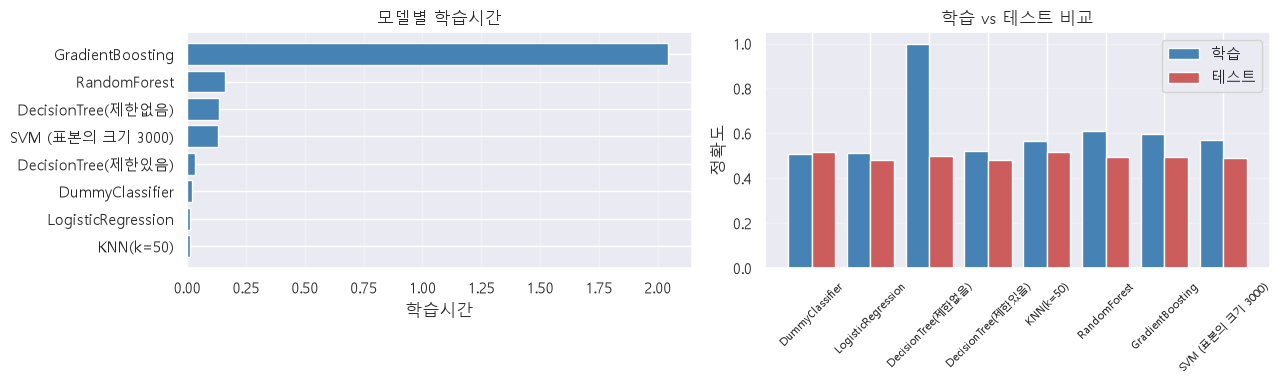

In [3]:
# 시각화하여 비교하기
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 학습 시간
r = result.sort_values("학습시간")

# barh(y축, x축): 가로 막대 그래프 (bar-horizontal)
axes[0].barh(r["모델"], r["학습시간"], color="steelblue")
axes[0].set_xlabel("학습시간")
axes[0].set_title("모델별 학습시간")
axes[0].grid(alpha=0.3, axis="x")

# 학습 vs 테스트 정확도 비교
x = np.arange(len(result))
# x: 가로축 위치 조정 (동일한 그래프를 겹치지 않게 표시하도록 설정)
# height: 막대 높이. 즉 표현할 데이터 값.
# width: 막대 너비(두께).
axes[1].bar(x=x - 0.2, width=0.4, height=result["학습"], 
            label="학습", color="steelblue")
axes[1].bar(x=x + 0.2, width=0.4, height=result["테스트"], 
            label="테스트", color="indianred")
# x축 눈금의 기본 위치
axes[1].set_xticks(x)
axes[1].set_xticklabels(result["모델"], rotation=45, fontsize=8)
axes[1].set_ylabel("정확도")
axes[1].set_title("학습 vs 테스트 비교")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()